In [15]:
# Core
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from scipy.stats import uniform, reciprocal, randint, loguniform
from sklearn.model_selection import RandomizedSearchCV

In [2]:
# load
df = pd.read_csv("/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/data/raw/fraudTrain.csv")
df_test =  pd.read_csv("/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/data/raw/fraudTest.csv")


print(df.shape)
print(df["is_fraud"].value_counts(normalize=True))


(1296675, 23)
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


# Undersampling

In [5]:
fraud = df[df["is_fraud"] == 1]
non_fraud = df[df["is_fraud"] == 0]

# keep all fraud + random sample of non-fraud
non_fraud_sample = non_fraud.sample(
    n= 5* len(fraud),   # ratio 1:100(fraud:nonfraud)
    random_state=42
)

df_subset = pd.concat([fraud, non_fraud_sample]).sample(frac=1, random_state=42)
print(df_subset["is_fraud"].value_counts(normalize=True))
print(df_subset.shape)

is_fraud
0    0.833333
1    0.166667
Name: proportion, dtype: float64
(45036, 23)


In [3]:

def preprocess_transactions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess a transaction DataFrame:
    - Parse timestamps and date of birth
    - Extract hour, day of week, and month
    - Compute integer age
    - Drop rows with missing target
    - Ensure is_fraud is integer

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with at least:
        ['trans_date_trans_time', 'dob', 'is_fraud']

    Returns
    -------
    pd.DataFrame
        Cleaned and feature-enriched DataFrame
    """
    df_subset = df.copy()

    # Convert timestamps
    ts = pd.to_datetime(df_subset["trans_date_trans_time"], errors="coerce")
    dob = pd.to_datetime(df_subset["dob"], errors="coerce")

    # Derived temporal features
    df_subset["hour"] = ts.dt.hour
    df_subset["day"] = ts.dt.dayofweek
    df_subset["month"] = ts.dt.month

    # Compute age in integer years
    ref = ts.fillna(pd.Timestamp.utcnow())
    df_subset["age"] = ((ref - dob).dt.days / 365).astype(int)

    # Drop rows without target and enforce integer type
    df_subset = df_subset.dropna(subset=["is_fraud"]).copy()
    df_subset["is_fraud"] = df_subset["is_fraud"].astype(int)

    return df_subset



In [6]:
# baseline feature sets
df_clean = preprocess_transactions(df_subset)
df_test_clean =  preprocess_transactions(df_test)

numeric_features = [
    "lat", "long", "merch_lat", "merch_long", "city_pop",
    "age", "hour", "day", "month"
]

amt_feature = ["amt"] 

categorical_features = ["category", "gender"]
                        #, "state"]

target_col = "is_fraud"

# split train/validation 
X = df_clean[numeric_features + amt_feature + categorical_features]
X_test = df_test_clean[numeric_features + amt_feature + categorical_features]
y = df_clean[target_col]
y_test = df_test_clean[target_col]

print(len(X))
X[:5]

45036


,lat,long,merch_lat,merch_long,city_pop,age,hour,day,month,amt,category,gender
645922,36.8421,-85.5396,36.905670,-85.136875,341,86,22,1,10,1004.44,misc_net,F
509664,40.8731,-96.1528,41.700683,-95.281589,1517,67,10,4,8,67.68,gas_transport,M
532246,31.8599,-102.7413,30.944892,-103.690696,23,49,10,5,8,4.19,shopping_net,F
685853,45.6710,-121.8686,46.527559,-121.924948,1288,83,22,5,10,9.84,health_fitness,F
1164647,43.5335,-96.3645,43.666337,-97.125800,899,25,0,4,5,784.09,misc_pos,F


In [7]:
amt_log_and_scale = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ('scale', StandardScaler())
])

# ColumnTransformer that combines the three blocks
preprocess= ColumnTransformer([
        ("amt_log_scaled", amt_log_and_scale, amt_feature), # ['amt']
        ("num_scaled", StandardScaler(),    numeric_features),  # other numerics
        ("cat_ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features), # categoricals
    ]
)

### RF to determine feature importance

In [7]:
# Cross validation
model = Pipeline([
    ("preprocess", preprocess), 
    ("rf", RandomForestClassifier(
        n_estimators=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42)),
])


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_val_score(
    model, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_results

array([0.99353409, 0.99336245, 0.99576329])

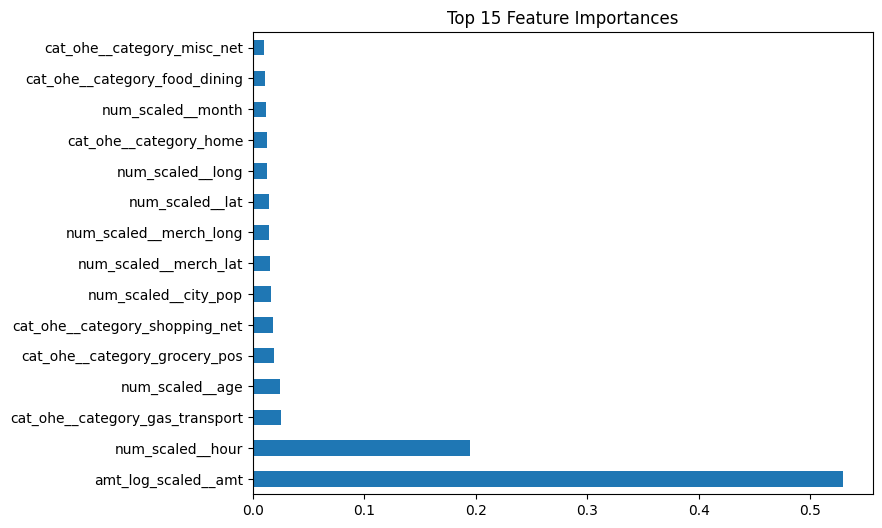

In [8]:
# After fitting your pipeline
model.fit(X, y)

# Extract the final model
rf = model.named_steps["rf"]

# Extract feature importances from RandomForest
importances = pd.Series(
    rf.feature_importances_,
    index=model.named_steps["preprocess"].get_feature_names_out()
)

# Plot
import matplotlib.pyplot as plt
importances.nlargest(15).plot(kind="barh", figsize=(8,6), title="Top 15 Feature Importances")
plt.show()


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.9995    0.9958    0.9977    553574
           1     0.4493    0.8834    0.5956      2145

    accuracy                         0.9954    555719
   macro avg     0.7244    0.9396    0.7967    555719
weighted avg     0.9974    0.9954    0.9961    555719

ROC-AUC: 0.9925185644464367
PR-AUC : 0.7834908654827266
[[551251   2323]
 [   250   1895]]


### SVC

In [10]:
svc_model = Pipeline([
    ("preprocess", preprocess), 
    ("svc",SVC(
        kernel="rbf",
        C=10.0,                 
        gamma="scale",
        class_weight="balanced",
        probability=True,       
        random_state=42)),
])

cv_svc_results = cross_val_score(
    svc_model, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_svc_results


array([0.99001493, 0.98936997, 0.99081556])

### XGBoost

In [11]:
# Compute class imbalance ratio: neg / pos
pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = neg / max(pos, 1)  # avoid div-by-zero

xgb_model = Pipeline([
    ("preprocess", preprocess), 
    ("xgb",XGBClassifier(
        n_estimators=20,          # with early stopping; set large
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42)),
])

cv_xgb_results = cross_val_score(
    xgb_model, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_xgb_results

array([0.98104132, 0.98314175, 0.98479405])

### One-class SVM for Anomaly Detection

In [12]:
from sklearn.svm import OneClassSVM

df_legit = df[df["is_fraud"] == 0].copy()
df_legit_clean = preprocess_transactions(df_legit)

X_legit = df_legit_clean[numeric_features + amt_feature + categorical_features]
Xt_legit = preprocess.transform(X_legit)

oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.01)  # nu ≈ expected outlier rate among training normals
oc.fit(Xt_legit)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,nu,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [13]:
# OCSVM: predict -> +1 = normal, -1 = outlier
y_pred = (oc.predict(Xt_test) == -1).astype(int)   # map to 1=anomaly/fraud, 0=normal

# Optional: continuous anomaly score (higher = more anomalous)
anomaly_score = -oc.decision_function(Xt_test)     # flip sign so higher = more fraud-like

print(classification_report(y_test, y_pred, digits=3))  # precision/recall/F1

# Threshold-free ranking metrics (use the continuous score)
print("PR-AUC:", average_precision_score(y_test, anomaly_score))
print("ROC-AUC:", roc_auc_score(y_test, anomaly_score))

              precision    recall  f1-score   support

           0      0.996     0.987     0.992    553574
           1      0.028     0.099     0.044      2145

    accuracy                          0.983    555719
   macro avg      0.512     0.543     0.518    555719
weighted avg      0.993     0.983     0.988    555719

PR-AUC: 0.029967246844573074
ROC-AUC: 0.7595840870391337


### Isolation Forest for anomaly detection

In [14]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score
# X_normal: ONLY legitimate rows (is_fraud==0)  -> shape [n_normals, n_features]
# X_eval, y_eval: mixed holdout with labels (0=normal, 1=fraud)

iso = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination=0.01,   # ≈ expected fraud rate in EVAL data (sets threshold for .predict)
    random_state=42,
    n_jobs=-1
)
iso.fit(Xt_legit)

# Hard predictions: +1=inlier, -1=outlier
y_pred = (iso.predict(Xt_test) == -1).astype(int)  # 1 = fraud

# Continuous anomaly score (higher = more anomalous, we flip sign)
scores = -iso.decision_function(Xt_test)

print(classification_report(y_test, y_pred, digits=3))
print("PR-AUC:",  average_precision_score(y_test, scores))
print("ROC-AUC:", roc_auc_score(y_test, scores))


              precision    recall  f1-score   support

           0      0.996     0.988     0.992    553574
           1      0.013     0.038     0.019      2145

    accuracy                          0.985    555719
   macro avg      0.504     0.513     0.506    555719
weighted avg      0.992     0.985     0.989    555719

PR-AUC: 0.0076793654064355645
ROC-AUC: 0.7030912858585401


Fraud Transactions are very similar with normal transactions and it can not differentiat between them. We will stick to the supervised models and try to improve them.

## Fine Tunning the models

### svm

In [12]:
from scipy.stats import uniform, reciprocal, randint, loguniform
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_distributions = {
    "svc__C": reciprocal(1e-2, 1e3),       # explore C logarithmically
    "svc__gamma": reciprocal(1e-4, 1e0),   # explore gamma logarithmically
    "svc__kernel": ["rbf", "poly", "sigmoid"]
}

# Define the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=svc_model,
    param_distributions=param_distributions,
    n_iter=10,                # number of random combinations to test
    scoring="roc_auc",        # can also use "average_precision" or "recall"
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit the search
random_search.fit(X, y)

# Best model and performance
print("Best parameters:", random_search.best_params_)
print("Best score", random_search.best_score_)

# You can access the best model directly
best_svc = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END svc__C=79.15074397656205, svc__gamma=0.024400607090817518, svc__kernel=poly; total time= 2.2min
[CV] END svc__C=79.15074397656205, svc__gamma=0.024400607090817518, svc__kernel=poly; total time= 2.4min
[CV] END svc__C=10.129197956845726, svc__gamma=0.06796578090758151, svc__kernel=poly; total time= 2.4min
[CV] END svc__C=79.15074397656205, svc__gamma=0.024400607090817518, svc__kernel=poly; total time= 2.4min
[CV] END svc__C=10.129197956845726, svc__gamma=0.06796578090758151, svc__kernel=poly; total time= 2.5min
[CV] END svc__C=10.129197956845726, svc__gamma=0.06796578090758151, svc__kernel=poly; total time= 2.5min
[CV] END svc__C=12.229467525390595, svc__gamma=0.02796485951606245, svc__kernel=rbf; total time= 2.9min
[CV] END svc__C=12.229467525390595, svc__gamma=0.02796485951606245, svc__kernel=rbf; total time= 3.3min
[CV] END svc__C=12.229467525390595, svc__gamma=0.02796485951606245, svc__kernel=rbf; total time= 3.0m

### RF 

In [13]:
# Define the hyperparameter search space
param_distributions = {
    "rf__n_estimators": randint(50, 200),         # number of trees
    "rf__max_depth": randint(3, 20),               # tree depth
    "rf__min_samples_split": randint(2, 10),
    "rf__min_samples_leaf": randint(1, 5),
    #"rf__max_features": uniform(0.3, 0.7),         # fraction of features used per split
    "rf__max_features" : ['auto', 'sqrt'],
    "rf__bootstrap": [True, False]
}

# Random search setup
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=10,             # number of random combos
    scoring="roc_auc",     # metric
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit the search
random_search.fit(X, y)

# Show best model & score
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# Retrieve the tuned model
best_rf = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=70; total time=   0.0s
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=70; total time=   0.0s
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=70; total time=   0.0s
[CV] END rf__bootstrap=True, rf__max_depth=13, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=149; total time=   0.0s
[CV] END rf__bootstrap=True, rf__max_depth=13, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=149; total time=   0.0s
[CV] END rf__bootstrap=True, rf__max_depth=13, rf__max_features=auto, rf__min_samples_leaf=4, rf__min_samples_split=6, rf__n_estimators=149; t

/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
9 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^

Best parameters: {'rf__bootstrap': False, 'rf__max_depth': 17, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 5, 'rf__n_estimators': 104}
Best score: 0.9973474244851387


### XGBoost

In [14]:
param_distributions = {
    "xgb__n_estimators": randint(300, 2000),
    "xgb__learning_rate": loguniform(1e-3, 2e-1),
    "xgb__max_depth": randint(3, 8),
    "xgb__min_child_weight": loguniform(1e-1, 10),
    "xgb__subsample": uniform(0.6, 0.4),
    "xgb__colsample_bytree": uniform(0.6, 0.4),
    "xgb__gamma": loguniform(1e-8, 1e1),
    "xgb__reg_lambda": loguniform(1e-2, 1e2),
    "xgb__reg_alpha": loguniform(1e-4, 1e1),
}


search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=10,                 # increase for a deeper search
    scoring="roc_auc",         # or "average_precision" (PR-AUC) which is great for imbalance
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

search.fit(X, y)

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

best_xgb = search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=3.6010467344475403, xgb__learning_rate=0.0483437145318464, xgb__max_depth=7, xgb__min_child_weight=1.5620693675639872, xgb__n_estimators=421, xgb__reg_alpha=0.000602521573620386, xgb__reg_lambda=0.017073967431528128, xgb__subsample=0.9464704583099741; total time=   0.7s
[CV] END xgb__colsample_bytree=0.6739417822102108, xgb__gamma=5.324289357128436, xgb__learning_rate=0.06075805702761636, xgb__max_depth=4, xgb__min_child_weight=0.6170217483403153, xgb__n_estimators=1295, xgb__reg_alpha=0.09761125443110447, xgb__reg_lambda=48.696409415209004, xgb__subsample=0.6353970008207678; total time=   1.5s
[CV] END xgb__colsample_bytree=0.8439986631130484, xgb__gamma=0.31532195143881037, xgb__learning_rate=0.0025056318905062307, xgb__max_depth=3, xgb__min_child_weight=0.3292759134423616, xgb__n_estimators=1711, xgb__reg_alpha=0.003618723330959626, xgb__reg_lambda=1.203017887115

## Voting Classifier

In [16]:
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    average_precision_score, roc_auc_score
)

voter = VotingClassifier(
    estimators=[("svc", best_svc), ("rf", best_rf), ("xgb", best_xgb)],
    voting="soft"
)

# 1) OOF probabilities (no leakage)
oof_proba = cross_val_predict(
    voter, X, y,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

# 2) Threshold-independent AUC metrics
pr_auc  = average_precision_score(y, oof_proba)  # PR-AUC
roc_auc = roc_auc_score(y, oof_proba)            # ROC-AUC
print(f"OOF PR-AUC:  {pr_auc:.6f}")
print(f"OOF ROC-AUC: {roc_auc:.6f}")

# 3) (Optional) Choose a threshold to hit recall ≥ target, then maximize precision
target_recall = 0.95
prec, rec, thr = precision_recall_curve(y, oof_proba)
thr_candidates = thr
prec_candidates = prec[:-1]
rec_candidates  = rec[:-1]

mask = rec_candidates >= target_recall
if mask.any():
    idx = np.argmax(prec_candidates[mask])
    best_t = float(thr_candidates[mask][idx])
else:
    f1 = 2 * prec_candidates * rec_candidates / (prec_candidates + rec_candidates + 1e-12)
    best_t = float(thr_candidates[np.argmax(f1)])

print("Chosen threshold:", best_t, "(target recall:", target_recall, ")")

# 4) Fit on all train and report at chosen threshold
voter.fit(X, y)
proba_train = voter.predict_proba(X)[:, 1]
y_pred_train = (proba_train >= best_t).astype(int)

print(classification_report(y, y_pred_train, digits=3))


OOF PR-AUC:  0.990548
OOF ROC-AUC: 0.997722
Chosen threshold: 0.5528236153642503 (target recall: 0.95 )
              precision    recall  f1-score   support

           0      0.995     0.994     0.995     37530
           1      0.969     0.977     0.973      7506

    accuracy                          0.991     45036
   macro avg      0.982     0.985     0.984     45036
weighted avg      0.991     0.991     0.991     45036



In [17]:
# Fit final weighted voter
y_pred = voter.predict(X_test)
y_prob = voter.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.9998    0.9882    0.9940    553574
           1     0.2369    0.9473    0.3790      2145

    accuracy                         0.9880    555719
   macro avg     0.6184    0.9677    0.6865    555719
weighted avg     0.9968    0.9880    0.9916    555719

ROC-AUC: 0.996859096325473
PR-AUC : 0.8248760866817132
[[547029   6545]
 [   113   2032]]


## Weighted Voting Classifier

In [42]:
from sklearn.model_selection import cross_val_score

svc_f1  = cross_val_score(best_svc, Xt_train, y, cv=cv, scoring="f1", n_jobs=-1).mean()
rf_f1   = cross_val_score(best_rf,  Xt_train, y, cv=cv, scoring="f1", n_jobs=-1).mean()
xgb_f1  = cross_val_score(best_xgb, Xt_train, y, cv=cv, scoring="f1", n_jobs=-1).mean()

w = np.array([svc_f1, rf_f1, xgb_f1])
w = w / (w.sum() + 1e-12)  # normalize (optional)

voter_w = VotingClassifier(
    estimators=[("svc", best_svc), ("rf", best_rf), ("xgb", best_xgb)],
    voting="soft",
    weights=w.tolist()
)

cv_f1_w = cross_val_score(voter_w, Xt_train, y, cv=cv, scoring="f1", n_jobs=-1)
print("Weighted Voting F1:", cv_f1_w.mean())

Weighted Voting F1: 0.9533733986953523


In [43]:
# Fit final weighted voter
voter_w.fit(Xt_train, y)

y_pred = voter_w.predict(Xt_test)
y_prob = voter_w.predict_proba(Xt_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.9998    0.9878    0.9938    553574
           1     0.2335    0.9566    0.3754      2145

    accuracy                         0.9877    555719
   macro avg     0.6167    0.9722    0.6846    555719
weighted avg     0.9969    0.9877    0.9914    555719

ROC-AUC: 0.9971785672830158
PR-AUC : 0.8183132363786226
[[546839   6735]
 [    93   2052]]


## Interpretation of the results

Confusion matrix [[547632, 5942], [99, 2046]]

    TP = 2,046, FN = 99 →  catching 95.4% of fraud (recall = 0.9538).

    FP = 5,942, TN = 547,632 → about 1.07% of legitimate transactions are falsely flagged.

Precision (fraud) = 0.256

    ~1 in 4 alerts is truly fraud; ~3 false alarms per true fraud (5,942 / 2,046 ≈ 2.9).

Accuracy = 0.989

    High, but mostly reflects the majority class (legitimate). Don’t over-weight this.

F1 (fraud) = 0.404

    Balanced summary for the minority class at the current threshold.

ROC-AUC = 0.997

    The model ranks transactions extremely well overall (threshold-independent).

PR-AUC = 0.835

    Good given the base rate of fraud (~0.386% = 2,145 / 555,719).

    Lift vs base rate ≈ 66× (0.256 / 0.00386) — very good.

In fraud detection:

Missing a fraud (false negative) usually costs money or reputation directly.
E.g., a $5,000 stolen credit card transaction you didn’t flag.

False positives (legitimate flagged as fraud) usually cost time or customer friction, but are less expensive than letting fraud through.

So, better to flag too many than to miss actual frauds, as long as you can handle the alert volume.

Goal in most systems: maximize recall, then tune threshold to improve precision without hurting recall too much.

# SMOTE

In [1]:
%pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imblearn]
Note: you may need to restart the kernel to use updated packages.


In [8]:
# baseline feature sets
df_clean = preprocess_transactions(df)

X = df_clean[numeric_features + amt_feature + categorical_features]
y = df_clean[target_col]

print(len(X))
X[:5]

1296675


,lat,long,merch_lat,merch_long,city_pop,age,hour,day,month,amt,category,gender
0,36.0788,-81.1781,36.011293,-82.048315,3495,30,0,1,1,4.97,misc_net,F
1,48.8878,-118.2105,49.159047,-118.186462,149,40,0,1,1,107.23,grocery_pos,F
2,42.1808,-112.2620,43.150704,-112.154481,4154,56,0,1,1,220.11,entertainment,M
3,46.2306,-112.1138,47.034331,-112.561071,1939,52,0,1,1,45.00,gas_transport,M
4,38.4207,-79.4629,38.674999,-78.632459,99,32,0,1,1,41.96,misc_pos,M


In [12]:
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
smote = SMOTE(sampling_strategy=0.2, k_neighbors=3, random_state=42)

## RF

In [13]:
# Cross validation
rf_smote = Pipeline([
    ("preprocess", preprocess),
    ("smote", smote),
    ("rf", RandomForestClassifier(
        n_estimators=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42)),
])

cv_rf_smote_results = cross_val_score(
    rf_smote, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_rf_smote_results

array([0.9801651 , 0.98210306, 0.98134017])

## svc

In [23]:
svc_smote = Pipeline([
    ("preprocess", preprocess),
    ("smote", smote),
    ("svc", SVC(
        kernel="rbf",
        C=10.0,                 
        gamma="scale",
        class_weight="balanced",
        probability=True,       
        random_state=42)),
])

cv_svc_smote_results = cross_val_score(
    svc_smote, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_svc_smote_results


KeyboardInterrupt: 

## XGBoost

In [19]:
from imblearn.pipeline import Pipeline as ImbPipeline

# Compute class imbalance ratio: neg / pos
pos = int((y == 1).sum()); neg = int((y == 0).sum())
scale_pos_weight = neg / max(pos, 1)

xgb_smote = ImbPipeline([
    ("preprocess", preprocess),
    ("smote", smote),
    ("xgb",XGBClassifier(
        n_estimators=20,          # with early stopping; set large
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42)),
])

cv_xgb_smote_results = cross_val_score(
    xgb_smote, X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_xgb_smote_results

array([0.97405567, 0.97012497, 0.97585825])

## Fine Tunning + SMOTE

### SVC

In [ ]:
from scipy.stats import uniform, reciprocal, randint, loguniform
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter search space
param_distributions = {
    "svc__C": reciprocal(1e-2, 1e3),       # explore C logarithmically
    "svc__gamma": reciprocal(1e-4, 1e0),   # explore gamma logarithmically
    "svc__kernel": ["rbf", "poly", "sigmoid"]
}

# Define the RandomizedSearchCV
random_search_svc_smote = RandomizedSearchCV(
    estimator=svc_model,
    param_distributions=param_distributions,
    n_iter=10,                # number of random combinations to test
    scoring="roc_auc",        # can also use "average_precision" or "recall"
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit the search
random_search_svc_smote.fit(X, y)

# Best model and performance
print("Best parameters:", random_search_svc_smote.best_params_)
print("Best score", random_search_svc_smote.best_score_)

# You can access the best model directly
best_svc_smote = random_search_svc_smote.best_estimator_

### RF

In [20]:
# Define the hyperparameter search space
param_distributions = {
    "rf__n_estimators": randint(50, 200),         # number of trees
    "rf__max_depth": randint(3, 20),               # tree depth
    "rf__min_samples_split": randint(2, 10),
    "rf__min_samples_leaf": randint(1, 10),
    #"max_features": uniform(0.3, 0.7),         # fraction of features used per split
    "rf__max_features" : ['auto', 'sqrt'],
    "rf__bootstrap": [True, False]
}

# Random search setup
random_search_rf_smote = RandomizedSearchCV(
    estimator=rf_smote,
    param_distributions=param_distributions,
    n_iter=10,             # number of random combos
    scoring="roc_auc",     # metric
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit the search
random_search_rf_smote.fit(X, y)

# Show best model & score
print("Best parameters:", random_search_rf_smote.best_params_)
print("Best score:", random_search_rf_smote.best_score_)

# Retrieve the tuned model
best_rf_smote = random_search_rf_smote.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=8, rf__min_samples_split=6, rf__n_estimators=70; total time=   0.8s
[CV] END rf__bootstrap=True, rf__max_depth=13, rf__max_features=auto, rf__min_samples_leaf=8, rf__min_samples_split=6, rf__n_estimators=149; total time=   1.0s
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=8, rf__min_samples_split=6, rf__n_estimators=70; total time=   1.5s
[CV] END rf__bootstrap=True, rf__max_depth=13, rf__max_features=auto, rf__min_samples_leaf=8, rf__min_samples_split=6, rf__n_estimators=149; total time=   1.1s
[CV] END rf__bootstrap=True, rf__max_depth=17, rf__max_features=auto, rf__min_samples_leaf=8, rf__min_samples_split=6, rf__n_estimators=70; total time=   1.6s
[CV] END rf__bootstrap=False, rf__max_depth=14, rf__max_features=auto, rf__min_samples_leaf=1, rf__min_samples_split=4, rf__n_estimators=108; 

/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
12 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           

Best parameters: {'rf__bootstrap': False, 'rf__max_depth': 17, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 5, 'rf__n_estimators': 57}
Best score: 0.9964172354681001


### XGBoost

In [22]:
param_distributions = {
    "xgb__n_estimators": randint(300, 2000),
    "xgb__learning_rate": loguniform(1e-3, 2e-1),
    "xgb__max_depth": randint(3, 8),
    "xgb__min_child_weight": loguniform(1e-1, 10),
    "xgb__subsample": uniform(0.6, 0.4),
    "xgb__colsample_bytree": uniform(0.6, 0.4),
    "xgb__gamma": loguniform(1e-8, 1e1),
    "xgb__reg_lambda": loguniform(1e-2, 1e2),
    "xgb__reg_alpha": loguniform(1e-4, 1e1),
}


random_search_xgb_smote = RandomizedSearchCV(
    estimator=xgb_smote,
    param_distributions=param_distributions,
    n_iter=10,                 # increase for a deeper search
    scoring="roc_auc",         # or "average_precision" (PR-AUC) which is great for imbalance
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

random_search_xgb_smote.fit(X, y)

print("Best params:", random_search_xgb_smote.best_params_)
print("Best CV F1:", random_search_xgb_smote.best_score_)

best_xgb_smote = random_search_xgb_smote.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=3.6010467344475403, xgb__learning_rate=0.0483437145318464, xgb__max_depth=7, xgb__min_child_weight=1.5620693675639872, xgb__n_estimators=421, xgb__reg_alpha=0.000602521573620386, xgb__reg_lambda=0.017073967431528128, xgb__subsample=0.9464704583099741; total time= 1.5min


/home/ruxandra/Desktop/Personal_Projects/fraud_detection_app/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=3.6010467344475403, xgb__learning_rate=0.0483437145318464, xgb__max_depth=7, xgb__min_child_weight=1.5620693675639872, xgb__n_estimators=421, xgb__reg_alpha=0.000602521573620386, xgb__reg_lambda=0.017073967431528128, xgb__subsample=0.9464704583099741; total time= 1.8min
[CV] END xgb__colsample_bytree=0.7216968971838151, xgb__gamma=0.00052821153945323, xgb__learning_rate=0.009860942908083906, xgb__max_depth=3, xgb__min_child_weight=1.120854708422937, xgb__n_estimators=810, xgb__reg_alpha=0.0004982752357076451, xgb__reg_lambda=0.14742753159914673, xgb__subsample=0.7465447373174767; total time= 1.8min
[CV] END xgb__colsample_bytree=0.749816047538945, xgb__gamma=3.6010467344475403, xgb__learning_rate=0.0483437145318464, xgb__max_depth=7, xgb__min_child_weight=1.5620693675639872, xgb__n_estimators=421, xgb__reg_alpha=0.000602521573620386, xgb__reg_lambda=0.017073967431528128, xgb__subsample=0.9464704583099741; total time= 2.3min
[

## Voting Classifier

In [23]:
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    average_precision_score, roc_auc_score
)

voter = VotingClassifier(
    estimators=[
        #("svc", best_svc_smote), 
        ("rf", best_rf_smote), ("xgb", best_xgb_smote)],
    voting="soft"
)

# 1) OOF probabilities (no leakage)
oof_proba = cross_val_predict(
    voter, X, y,
    cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

# 2) Threshold-independent AUC metrics
pr_auc  = average_precision_score(y, oof_proba)  # PR-AUC
roc_auc = roc_auc_score(y, oof_proba)            # ROC-AUC
print(f"OOF PR-AUC:  {pr_auc:.6f}")
print(f"OOF ROC-AUC: {roc_auc:.6f}")

# 3) (Optional) Choose a threshold to hit recall ≥ target, then maximize precision
target_recall = 0.95
prec, rec, thr = precision_recall_curve(y, oof_proba)
thr_candidates = thr
prec_candidates = prec[:-1]
rec_candidates  = rec[:-1]

mask = rec_candidates >= target_recall
if mask.any():
    idx = np.argmax(prec_candidates[mask])
    best_t = float(thr_candidates[mask][idx])
else:
    f1 = 2 * prec_candidates * rec_candidates / (prec_candidates + rec_candidates + 1e-12)
    best_t = float(thr_candidates[np.argmax(f1)])

print("Chosen threshold:", best_t, "(target recall:", target_recall, ")")

# 4) Fit on all train and report at chosen threshold
voter.fit(X, y)
proba_train = voter.predict_proba(X)[:, 1]
y_pred_train = (proba_train >= best_t).astype(int)

print(classification_report(y, y_pred_train, digits=3))


OOF PR-AUC:  0.902659
OOF ROC-AUC: 0.997894
Chosen threshold: 0.5739705343298611 (target recall: 0.95 )
              precision    recall  f1-score   support

           0      1.000     0.992     0.996   1289169
           1      0.426     0.994     0.596      7506

    accuracy                          0.992   1296675
   macro avg      0.713     0.993     0.796   1296675
weighted avg      0.997     0.992     0.994   1296675



In [25]:
# Fit final weighted voter
y_pred = voter.predict(X_test)
y_prob = voter.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.9998    0.9901    0.9949    553574
           1     0.2698    0.9441    0.4196      2145

    accuracy                         0.9899    555719
   macro avg     0.6348    0.9671    0.7073    555719
weighted avg     0.9970    0.9899    0.9927    555719

ROC-AUC: 0.9971111915827527
PR-AUC : 0.8574962108644726
[[548093   5481]
 [   120   2025]]


## SMOTE + Tomek 

**TO DO**

In [ ]:
from imblearn.combine import SMOTETomek

SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=100, random_state=13))

